# 电商文本挖掘-拜耳公司驱虫市场

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [86]:
# 中文
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False  # 负号

## 针对各个子类目市场近三年的交易额数据

In [3]:
# 近三年的交易额数据
import glob

In [5]:
import os

# change directory 修改工作目录
os.chdir(r'C:\Users\ijeff\Desktop\Python2106\day15_电商文本挖掘\data\驱虫剂市场')

In [11]:
files = glob.glob('*近三年*')
files

['灭鼠杀虫剂市场近三年交易额.xlsx',
 '电蚊香套装市场近三年交易额.xlsx',
 '盘香灭蟑香蚊香盘市场近三年交易额.xlsx',
 '蚊香加热器市场近三年交易额.xlsx',
 '蚊香液市场近三年交易额.xlsx',
 '蚊香片市场近三年交易额.xlsx',
 '防霉防蛀片市场近三年交易额.xlsx']

In [12]:
# 灭鼠杀虫剂市场近三年交易额.
pd.read_excel(files[0]).head(2)

,时间,交易金额
0,2018-10-01,1.136548e+08
1,2018-09-01,1.440261e+08


In [13]:
# 电蚊香套装市场近三年交易额
pd.read_excel(files[1]).head(2)

,时间,交易金额
0,43374,106531.29
1,43344,105666.63


In [20]:
pd.read_excel(files[6]).head(2)

,时间,交易金额
0,43374,8541153.59
1,43344,8825870.43


In [26]:
# 43374 时间需要转换成 2018-10-01

pd.to_datetime(43374, unit='D', origin='1899-12-30')

pd.to_datetime(pd.read_excel(files[6]).时间, unit='D', origin='1899-12-30')


0    2018-10-01
1    2018-09-01
2    2018-08-01
3    2018-07-01
4    2018-06-01
5    2018-05-01
6    2018-04-01
7    2018-03-01
8    2018-02-01
9    2018-01-01
10   2017-12-01
11   2017-11-01
12   2017-10-01
13   2017-09-01
14   2017-08-01
15   2017-07-01
16   2017-06-01
17   2017-05-01
18   2017-04-01
19   2017-03-01
20   2017-02-01
21   2017-01-01
22   2016-12-01
23   2016-11-01
24   2016-10-01
25   2016-09-01
26   2016-08-01
27   2016-07-01
28   2016-06-01
29   2016-05-01
30   2016-04-01
31   2016-03-01
32   2016-02-01
33   2016-01-01
34   2015-12-01
35   2015-11-01
Name: 时间, dtype: datetime64[ns]

In [33]:
#  遍历这7个交易数据，并整合在一起

df_list = [ ]

for i, file in enumerate(files):
    # 读取每一个文件的内容DataFrame
    df = pd.read_excel(file)
    
    # 将后6个文件的时间转换一下
    if i > 0:
        df.时间 = pd.to_datetime(df.时间, unit='D', origin='1899-12-30')
    
    # 把时间这一列作为索引，方便后面合并
    df.set_index(keys='时间', inplace=True)
    
    # 修改列索引
    # 灭鼠杀虫剂市场近三年交易额. => "灭鼠杀虫剂"
    df.columns=[ file.split('市场')[0] ]
    
    df_list.append(df)


In [34]:
df_list[0], df_list[1]

(                   灭鼠杀虫剂
 时间                      
 2018-10-01  1.136548e+08
 2018-09-01  1.440261e+08
 2018-08-01  1.540426e+08
 2018-07-01  1.480032e+08
 2018-06-01  1.359438e+08
 2018-05-01  1.241642e+08
 2018-04-01  7.509661e+07
 2018-03-01  5.918182e+07
 2018-02-01  2.292138e+07
 2018-01-01  3.653873e+07
 2017-12-01  4.292283e+07
 2017-11-01  5.838217e+07
 2017-10-01  8.226882e+07
 2017-09-01  1.010081e+08
 2017-08-01  1.049504e+08
 2017-07-01  1.116729e+08
 2017-06-01  1.051463e+08
 2017-05-01  9.185035e+07
 2017-04-01  5.363586e+07
 2017-03-01  4.078967e+07
 2017-02-01  3.467502e+07
 2017-01-01  2.047156e+07
 2016-12-01  3.546668e+07
 2016-11-01  4.780625e+07
 2016-10-01  6.339722e+07
 2016-09-01  6.864724e+07
 2016-08-01  7.610885e+07
 2016-07-01  7.832954e+07
 2016-06-01  7.693264e+07
 2016-05-01  5.812696e+07
 2016-04-01  3.762602e+07
 2016-03-01  2.952610e+07
 2016-02-01  1.500135e+07
 2016-01-01  2.107822e+07
 2015-12-01  2.472756e+07
 2015-11-01  3.303873e+07,
           

In [36]:
# 水平合并 axis=1
df = pd.concat(df_list, axis=1)
df

,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
时间,,,,,,,
2018-10-01,1.136548e+08,106531.29,4171283.35,315639.48,7.814546e+06,1032414.29,8541153.59
2018-09-01,1.440261e+08,105666.63,6784500.17,457366.41,1.065497e+07,1566651.88,8825870.43
2018-08-01,1.540426e+08,201467.03,10709683.41,746513.13,1.783558e+07,2617149.00,6320153.44
2018-07-01,1.480032e+08,438635.29,16589184.89,1871757.00,3.887792e+07,6209040.06,6302595.06
2018-06-01,1.359438e+08,953749.78,23526385.73,3641025.92,7.649909e+07,12484919.63,7047206.98
2018-05-01,1.241642e+08,1238967.37,28118581.25,5032466.78,1.050396e+08,15309721.94,7942340.44
2018-04-01,7.509661e+07,841051.93,16420341.87,3130513.43,6.254165e+07,7954875.07,7031364.60
2018-03-01,5.918182e+07,475177.48,7900094.91,1198332.81,2.632447e+07,2950648.32,6051561.02
2018-02-01,2.292138e+07,33232.95,545917.66,75714.46,2.235774e+06,218915.63,1393948.47


In [37]:
# 重置索引
df.reset_index(inplace=True)

In [38]:
df

,时间,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
0,2018-10-01,1.136548e+08,106531.29,4171283.35,315639.48,7.814546e+06,1032414.29,8541153.59
1,2018-09-01,1.440261e+08,105666.63,6784500.17,457366.41,1.065497e+07,1566651.88,8825870.43
2,2018-08-01,1.540426e+08,201467.03,10709683.41,746513.13,1.783558e+07,2617149.00,6320153.44
3,2018-07-01,1.480032e+08,438635.29,16589184.89,1871757.00,3.887792e+07,6209040.06,6302595.06
4,2018-06-01,1.359438e+08,953749.78,23526385.73,3641025.92,7.649909e+07,12484919.63,7047206.98
5,2018-05-01,1.241642e+08,1238967.37,28118581.25,5032466.78,1.050396e+08,15309721.94,7942340.44
6,2018-04-01,7.509661e+07,841051.93,16420341.87,3130513.43,6.254165e+07,7954875.07,7031364.60
7,2018-03-01,5.918182e+07,475177.48,7900094.91,1198332.81,2.632447e+07,2950648.32,6051561.02
8,2018-02-01,2.292138e+07,33232.95,545917.66,75714.46,2.235774e+06,218915.63,1393948.47
9,2018-01-01,3.653873e+07,54305.20,592663.20,86670.45,1.759451e+06,298146.11,2607776.07


#### 补全2018年11月12月交易数据

In [ ]:
# 由于其中的时间列是从2015年11月到2018年10月,而我们需要的是2016-2018年每
# 月完整的数据(方便从年变化的角度分析产品) · 这里我们假设: 
#     - 每年各月之间没有明显规律的周期性变化(近似认为月和月之间的相关性不大) 
#     - 每年对应月份的数据是线性变化的(一是因为数据少,二是认为随着年份的增长,
# 交易额在大环境下是稳步变化的) · 故这里我们可以简单的用线性回归预测
# - 即对于每个子类目市场,用15,16,17年的11/12月销售金额预测18年的对应月份

In [ ]:
#  线性回归预测补全
#   训练数据： 用15,16,17年的11/12月销售金额
#   预测数据： 18年的对应月份

In [50]:
# 单独考虑11月份 的 一个产品（灭鼠杀虫剂）

#   2015年11月，2016年11月，2017年11月  的 灭鼠杀虫剂

df.时间.dt.year  # 年
df.时间.dt.month  # 月

df.loc[df.时间.dt.month == 11]
# df.loc[df.时间.dt.month == 11, '灭鼠杀虫剂']


,时间,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
11,2017-11-01,58382172.96,94993.76,1581530.20,168141.79,4257593.87,617094.94,5447184.43
23,2016-11-01,47806248.76,106291.23,1473418.20,82835.82,2758827.44,512990.23,4975519.21
35,2015-11-01,33038726.31,185094.22,1197791.27,86889.91,1579795.72,325744.43,3364112.14


#### 使用线性回归预测，补全2018年11月12月的交易金额数据

In [45]:
from sklearn.linear_model import LinearRegression

In [54]:

# 单独考虑11月份 的 一个产品（灭鼠杀虫剂）

x_train = np.array([2015, 2016, 2017]).reshape(-1, 1)
y_train = df.loc[df.时间.dt.month == 11, '灭鼠杀虫剂'][: : -1]
x_test = np.array([2018]).reshape(-1, 1)

y_train

# 线性回归
# 训练
linear = LinearRegression()
linear.fit(x_train, y_train)

# 预测
linear.predict(x_test)

array([71752495.99333572])

In [48]:
df.head(3)

,时间,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
0,2018-10-01,1.136548e+08,106531.29,4171283.35,315639.48,7814546.15,1032414.29,8541153.59
1,2018-09-01,1.440261e+08,105666.63,6784500.17,457366.41,10654973.47,1566651.88,8825870.43
2,2018-08-01,1.540426e+08,201467.03,10709683.41,746513.13,17835577.80,2617149.00,6320153.44


In [56]:
import datetime

In [65]:
# 同时考虑11月12月，所有产品

# 遍历月份
for month in [11, 12]:
    
    pred_list = [datetime.datetime(year=2018, month=month, day=1)]
    
    # 遍历所有产品
    for col in df.columns[1 : ]:
        # 训练数据
        x_train = np.array([2015, 2016, 2017]).reshape(-1, 1)
        y_train = df.loc[df.时间.dt.month == month, col][ : : -1]
        x_test = np.array([2018]).reshape(-1, 1)
        
        # 线性回归
        # 训练
        linear = LinearRegression()
        linear.fit(x_train, y_train)

        # 预测
        y_pred = linear.predict(x_test)
        # print(month, col, y_pred)
        
        pred_list.append(y_pred[0])
        
#     display(pred_list)
    # pred_list 转成dataframe再加入df
    # 变成1行多列
    pred_array = np.array(pred_list).reshape(1, -1)
#     display(pred_array)
    # 转成DataFrame 
    pred_df = pd.DataFrame(data=pred_array, columns=df.columns)
    display(pred_df)
    
    # 拼接
    df = pred_df.append(df)

,时间,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
0,2018-11-01,7.17525e+07,38692.6,1.80132e+06,193874,5.5432e+06,776627,6.67868e+06


,时间,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
0,2018-12-01,5.25676e+07,50204.5,928554,86849.2,3.08149e+06,426813,3.95872e+06


In [66]:
df

,时间,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
0,2018-12-01,5.25676e+07,50204.5,928554,86849.2,3.08149e+06,426813,3.95872e+06
0,2018-11-01,7.17525e+07,38692.6,1.80132e+06,193874,5.5432e+06,776627,6.67868e+06
0,2018-10-01,1.13655e+08,106531,4.17128e+06,315639,7.81455e+06,1.03241e+06,8.54115e+06
1,2018-09-01,1.44026e+08,105667,6.7845e+06,457366,1.0655e+07,1.56665e+06,8.82587e+06
2,2018-08-01,1.54043e+08,201467,1.07097e+07,746513,1.78356e+07,2.61715e+06,6.32015e+06
3,2018-07-01,1.48003e+08,438635,1.65892e+07,1.87176e+06,3.88779e+07,6.20904e+06,6.3026e+06
4,2018-06-01,1.35944e+08,953750,2.35264e+07,3.64103e+06,7.64991e+07,1.24849e+07,7.04721e+06
5,2018-05-01,1.24164e+08,1.23897e+06,2.81186e+07,5.03247e+06,1.0504e+08,1.53097e+07,7.94234e+06
6,2018-04-01,7.50966e+07,841052,1.64203e+07,3.13051e+06,6.25417e+07,7.95488e+06,7.03136e+06
7,2018-03-01,5.91818e+07,475177,7.90009e+06,1.19833e+06,2.63245e+07,2.95065e+06,6.05156e+06


In [69]:
df.reset_index(drop=True, inplace=True)

In [70]:
df

,时间,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
0,2018-12-01,5.25676e+07,50204.5,928554,86849.2,3.08149e+06,426813,3.95872e+06
1,2018-11-01,7.17525e+07,38692.6,1.80132e+06,193874,5.5432e+06,776627,6.67868e+06
2,2018-10-01,1.13655e+08,106531,4.17128e+06,315639,7.81455e+06,1.03241e+06,8.54115e+06
3,2018-09-01,1.44026e+08,105667,6.7845e+06,457366,1.0655e+07,1.56665e+06,8.82587e+06
4,2018-08-01,1.54043e+08,201467,1.07097e+07,746513,1.78356e+07,2.61715e+06,6.32015e+06
5,2018-07-01,1.48003e+08,438635,1.65892e+07,1.87176e+06,3.88779e+07,6.20904e+06,6.3026e+06
6,2018-06-01,1.35944e+08,953750,2.35264e+07,3.64103e+06,7.64991e+07,1.24849e+07,7.04721e+06
7,2018-05-01,1.24164e+08,1.23897e+06,2.81186e+07,5.03247e+06,1.0504e+08,1.53097e+07,7.94234e+06
8,2018-04-01,7.50966e+07,841052,1.64203e+07,3.13051e+06,6.25417e+07,7.95488e+06,7.03136e+06
9,2018-03-01,5.91818e+07,475177,7.90009e+06,1.19833e+06,2.63245e+07,2.95065e+06,6.05156e+06


### 按照年份查看驱虫市场的总体变化趋势
- 所有子类目市场每年的交易金额总和;折线图表示变化

In [71]:
df.insert(1, '年份', df.时间.dt.year)

In [73]:
df.head()

,时间,年份,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
0,2018-12-01,2018,5.25676e+07,50204.5,928554,86849.2,3.08149e+06,426813,3.95872e+06
1,2018-11-01,2018,7.17525e+07,38692.6,1.80132e+06,193874,5.5432e+06,776627,6.67868e+06
2,2018-10-01,2018,1.13655e+08,106531,4.17128e+06,315639,7.81455e+06,1.03241e+06,8.54115e+06
3,2018-09-01,2018,1.44026e+08,105667,6.7845e+06,457366,1.0655e+07,1.56665e+06,8.82587e+06
4,2018-08-01,2018,1.54043e+08,201467,1.07097e+07,746513,1.78356e+07,2.61715e+06,6.32015e+06


In [76]:
df = df.iloc[ : -2].copy()
df.tail()

,时间,年份,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
31,2016-05-01,2016,5.8127e+07,2.05988e+06,9.9128e+06,1.61836e+06,4.77769e+07,7.47442e+06,5.46936e+06
32,2016-04-01,2016,3.7626e+07,1.03499e+06,4.68791e+06,758207,2.43292e+07,3.43526e+06,5.25362e+06
33,2016-03-01,2016,2.95261e+07,352013,1.20457e+06,246107,6.65638e+06,746709,3.48119e+06
34,2016-02-01,2016,1.50014e+07,96979.5,449199,36193.8,693907,109108,1.27481e+06
35,2016-01-01,2016,2.10782e+07,108413,619042,49670.2,482889,113285,1.56239e+06


In [97]:
df2 = df.groupby(by='年份').sum().copy()
df2

,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
年份,,,,,,,
2016,6.080471e+08,7666572.12,4.785285e+07,5.905205e+06,1.704905e+08,27980839.47,50023001.94
2017,8.477740e+08,9377531.68,8.635539e+07,1.055284e+07,3.300656e+08,49068587.96,62678822.18
2018,1.137893e+09,4537682.09,1.180885e+08,1.683672e+07,3.582077e+08,51845921.56,72701365.23


In [98]:
# 统计每年的所有类目的总交易额
df2.sum(axis=1)

年份
2016    9.179661e+08
2017    1.395873e+09
2018    1.760111e+09
dtype: float64

In [85]:
# 中文
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False  # 负号

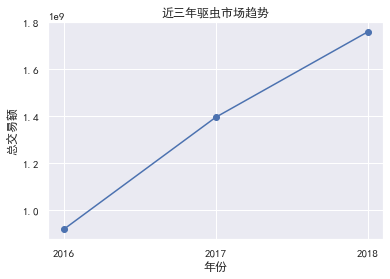

In [99]:
# 画图

df2.sum(axis=1).plot(marker='o')
plt.xticks([2016, 2017, 2018])
plt.ylabel('总交易额')
plt.title('近三年驱虫市场趋势')
plt.show()

# 结论：
# 可以看出:  近三年呈增长趋势,整个市场倾向于成长期和成熟期

### 查看各类目市场三年内销售额总和的变化趋势

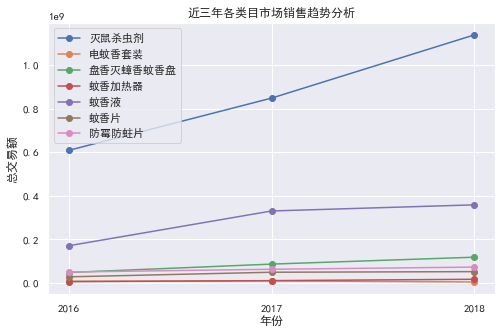

In [100]:
df2.plot(figsize=(8, 5), marker='o')
plt.xticks([2016, 2017, 2018])
plt.ylabel('总交易额')
plt.title('近三年各类目市场销售趋势分析')
plt.show()


# 结论：
# 直观的看灭鼠杀虫剂和蚊香液都有较大的机会


###  查看各类目市场三年内销售额总和的占比

In [101]:
df2

,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
年份,,,,,,,
2016,6.080471e+08,7666572.12,4.785285e+07,5.905205e+06,1.704905e+08,27980839.47,50023001.94
2017,8.477740e+08,9377531.68,8.635539e+07,1.055284e+07,3.300656e+08,49068587.96,62678822.18
2018,1.137893e+09,4537682.09,1.180885e+08,1.683672e+07,3.582077e+08,51845921.56,72701365.23


In [104]:
# 每一年的 总交易额
df3 = df2.sum(axis=1)
df3

年份
2016    9.179661e+08
2017    1.395873e+09
2018    1.760111e+09
dtype: float64

In [109]:
# 每一年 各类目销售额占比
year_df2 = df2.divide(df3, axis='index')
year_df2

,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
年份,,,,,,,
2016,0.662385,0.008352,0.052129,0.006433,0.185726,0.030481,0.054493
2017,0.607343,0.006718,0.061865,0.007560,0.236458,0.035153,0.044903
2018,0.646489,0.002578,0.067092,0.009566,0.203514,0.029456,0.041305


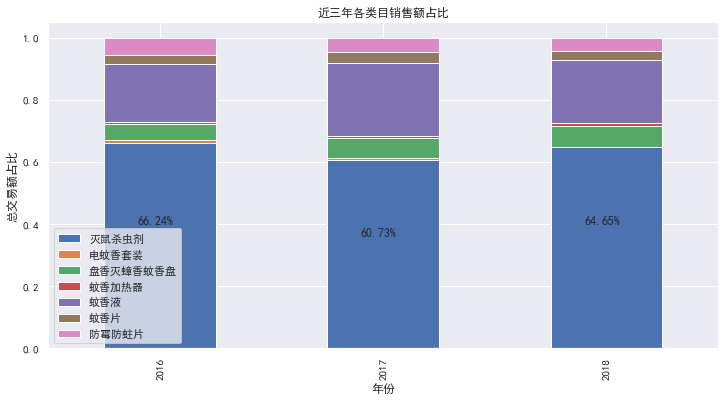

In [119]:
# 画图
year_df2.plot(kind='bar', stacked=True, figsize=(12, 6) )
plt.title('近三年各类目销售额占比')
plt.ylabel('总交易额占比')

plt.text(0-0.1, 0.4, '66.24%')
plt.text(1-0.1, 0.36, '60.73%')
plt.text(2-0.1, 0.4, '64.65%')

plt.show()


# 可见灭鼠杀虫剂和蚊香液可进一步扩展, 就需要与甲方业务人员进一步沟通


### 进一步分析各类目市场16-17年17-18年增幅

In [ ]:
# 16-17年增幅 = (2017年销售额 - 2016年销售额) / 2016年销售额

# 17-18年增幅 = (2018年销售额 - 2017年销售额) / 2017年销售额


In [120]:
df2

,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
年份,,,,,,,
2016,6.080471e+08,7666572.12,4.785285e+07,5.905205e+06,1.704905e+08,27980839.47,50023001.94
2017,8.477740e+08,9377531.68,8.635539e+07,1.055284e+07,3.300656e+08,49068587.96,62678822.18
2018,1.137893e+09,4537682.09,1.180885e+08,1.683672e+07,3.582077e+08,51845921.56,72701365.23


In [121]:
growth_16_17 = ( df2.loc[2017] - df2.loc[2016] ) / df2.loc[2016]
growth_17_18 = ( df2.loc[2018] - df2.loc[2017] ) / df2.loc[2017]

In [123]:
growth_16_17

灭鼠杀虫剂       0.394257
电蚊香套装       0.223171
盘香灭蟑香蚊香盘    0.804603
蚊香加热器       0.787041
蚊香液         0.935976
蚊香片         0.753650
防霉防蛀片       0.253000
dtype: float64

In [124]:
growth_17_18

灭鼠杀虫剂       0.342213
电蚊香套装      -0.516111
盘香灭蟑香蚊香盘    0.367471
蚊香加热器       0.595468
蚊香液         0.085262
蚊香片         0.056601
防霉防蛀片       0.159903
dtype: float64

In [127]:
# 方便画图， DataFrame
df4 = pd.concat((growth_16_17, growth_17_18), axis=1)
df4.columns = ['16-17', '17-18']
df4

,16-17,17-18
灭鼠杀虫剂,0.394257,0.342213
电蚊香套装,0.223171,-0.516111
盘香灭蟑香蚊香盘,0.804603,0.367471
蚊香加热器,0.787041,0.595468
蚊香液,0.935976,0.085262
蚊香片,0.753650,0.056601
防霉防蛀片,0.253000,0.159903


In [130]:
df4.T

,灭鼠杀虫剂,电蚊香套装,盘香灭蟑香蚊香盘,蚊香加热器,蚊香液,蚊香片,防霉防蛀片
16-17,0.394257,0.223171,0.804603,0.787041,0.935976,0.753650,0.253000
17-18,0.342213,-0.516111,0.367471,0.595468,0.085262,0.056601,0.159903


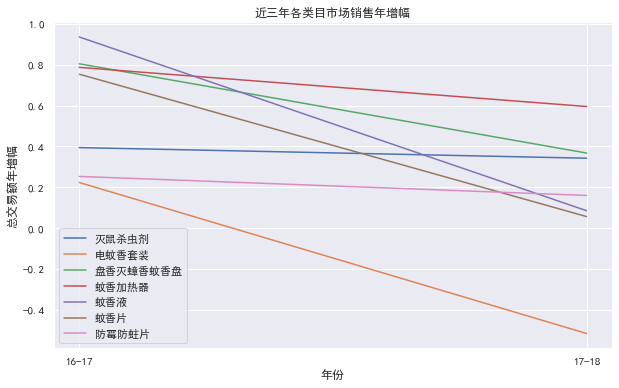

In [137]:
df4.T.plot(figsize=(10, 6))
plt.xticks([0, 1], ['16-17', '17-18'])
plt.title('近三年各类目市场销售年增幅')
plt.xlabel('年份')
plt.ylabel('总交易额年增幅')
plt.show()


# 可见除了灭鼠杀虫剂，蚊香加热器，防霉防蛀片比较稳定
#   蚊香液，盘香灭蟑香蚊香盘，蚊香片 增幅16-17比较高的，17-18增幅下降明显
